# KL divergence computation for MGD on LAGRANGIAN TURBULENCE data 

In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_experiment import * 
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [2]:
import math
def compute_expected_kl_divergence(theta_runs, phi_X_list):
    """
    E_runs[ log E_X[ exp(-(theta_n - theta_star)^T phi_n(X)) ] ]

    Args:
        theta_runs: [N_runs, T, num_features] (or list of [T, num_features])
        phi_X_list: list of length N_runs, each [B, num_features] -- run n's
                    OWN phi_X, evaluated with that seed's own fitted potentials.
                    (Not a single shared phi_X: theta_n lives in the basis
                    defined by that seed's own active statistics.)
        theta_star: computed here as mean(theta_runs, dim=0) -- ASSUMPTION,
                    see caveat below.
    """
    if isinstance(theta_runs, list):
        theta_runs = torch.stack(theta_runs)
    N_runs, T, num_params = theta_runs.shape

    assert len(phi_X_list) == N_runs, (
        f"phi_X_list has {len(phi_X_list)} entries but theta_runs has {N_runs} runs"
    )
    for n, phi_X_n in enumerate(phi_X_list):
        assert phi_X_n.shape[-1] == num_params, (
            f"run {n}: phi_X has {phi_X_n.shape[-1]} features, "
            f"theta has {num_params}"
        )

    device = theta_runs.device
    theta_star = theta_runs.mean(dim=0)  # [T, num_params]
    kl_divergence_t = torch.zeros(T, device=device, dtype=torch.float64)

    for n in range(N_runs):
        theta_n = theta_runs[n]                              # [T, num_params]
        phi_X_n = phi_X_list[n].to(device)                    # [B_n, num_params]
        B_n = phi_X_n.shape[0]
        log_B_n = math.log(B_n)

        negative_delta_theta = -(theta_n - theta_star)         # [T, num_params]
        dot_product = torch.matmul(negative_delta_theta, phi_X_n.T)  # [T, B_n]
        log_inner = torch.logsumexp(dot_product.double(), dim=1) - log_B_n  # [T]
        kl_divergence_t += log_inner

    kl_divergence_t /= N_runs
    return kl_divergence_t.to(theta_runs.dtype)

from pathlib import Path

# Persistent across reruns, same pattern as `results`
if 'config_by_seed' not in locals() and 'config_by_seed' not in globals():
    config_by_seed = {}
if 'potentials_by_seed' not in locals() and 'potentials_by_seed' not in globals():
    potentials_by_seed = {}

def get_potentials_for_seed(key, M, base_args, root, device):
    """Lazily load+cache a seed's fitted potentials, reconstructing from disk
    if this session doesn't have them cached yet."""
    if key in potentials_by_seed:
        return potentials_by_seed[key]
    if key not in config_by_seed:
        raise KeyError(
            f"No resolved_config recorded for {key} — it was probably loaded into "
            f"`results` in an earlier session/cell before config_by_seed existed. "
            f"Re-run the loading loop (with config_by_seed populated) for this seed."
        )
    resolved_config = config_by_seed[key]
    potentials_k = load_potentials_for_config(
        resolved_config, M, J=base_args.J, Q=base_args.Q,
        terms=base_args.terms, root=root, device=device
    )
    potentials_by_seed[key] = potentials_k
    return potentials_k

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)

    potentials = get_1d_potentials(
        terms, J, filters, Q,
        scalar_param=None, parallel=False,
        filters_Q=filters_Q, filters_Phi=filters_Phi,
    )

    potentials_dir = Path(root) / "experiments" / resolved_config / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(
            f"No fitted_potentials dir for {resolved_config} at {potentials_dir}"
        )

    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters   # whichever bank THIS potential actually got assigned
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded

    return potentials


def compute_phi_X(potentials, x1):
    evaluated_features = []
    for p in potentials.values():
        feat = p(x1)
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
        evaluated_features.append(feat)
    return torch.cat(evaluated_features, dim=-1)

In [3]:
# Default parameters
J = 8
Q = 3
M = 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 1e-06
n_subsample = 200
regularization = 1e-2

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# LAGRANGIAN TURBULENCE DATA 
Data = load_turbulence_1d().to(device) 
print(Data.shape, Data.device) 
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800]) cuda:0
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 256])


In [4]:
terms=[
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]

filters = return_Filters(M, J, 1, device=device) 
potentials = get_1d_potentials(
    terms, J, filters, Q,
    scalar_param=None, parallel=False,
    )

base_args = SimpleNamespace(
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    #timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1
)

In [5]:
experiments_to_compare = {
    f'seed{i}': {"seed": i} for i in range(1)
}

In [6]:
import gc
import torch
import os 
import re 


# Assuming `results` already exists or you want to start fresh:
if 'results' not in locals() and 'results' not in globals():
    results = {}

pattern = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-06_seed_(\d+)_terms2f1130a8_20260723_1708$"
)

print("Scanning directory once...")
# 2. Grab all directory contents just once to avoid heavy repetitive disk lookups
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
# 1. Define the 4 separate chunk ranges
chunks = [
    range(0, 2),   # 0 to 12
    #range(63, 75),  # 13 to 24
    #range(75, 88),  # 25 to 37
    #range(88, 100)   # 38 to 49
]

for chunk_idx, seed_range in enumerate(chunks, 1):
    print(f"=== PROCESSING CHUNK {chunk_idx}/4 (Seeds {seed_range.start} to {seed_range.stop - 1}) ===")

    current_chunk_runs = {}
    for folder in all_folders:
        match = pattern.match(folder)
        if match:
            seed_val = int(match.group(1))
            if seed_val in seed_range:
                current_chunk_runs[f"seed{seed_val}"] = folder

    KEYS_TO_KEEP = {'xt', 'theta_t', 'Theta_reg', 'dH_t_bound', 't'}
    potentials_by_seed = {} 
    for key, resolved_config in sorted(current_chunk_runs.items(),
                                        key=lambda x: int(x[0].replace("seed", ""))):
        print(f"  [{key}] Loading: {resolved_config}")
        loaded_data = try_load_experiment(root, resolved_config, device)

        if loaded_data and loaded_data.get('loaded', False):
            filtered_data = {k: loaded_data[k] for k in KEYS_TO_KEEP if k in loaded_data}
    
            potentials_k = load_potentials_for_config(
                resolved_config, M, J=base_args.J, Q=base_args.Q,
                terms=base_args.terms, root=root, device=device
            )
            phi_X_k = compute_phi_X(potentials_k, x1)
            filtered_data['phi_X'] = phi_X_k
            filtered_data['num_potentials'] = phi_X_k.shape[-1]
    
            expected = filtered_data['theta_t'].shape[-1]
            if phi_X_k.shape[-1] != expected:
                print(f"    -> MISMATCH for {key}: skipping.")
                del loaded_data, potentials_k, phi_X_k
                continue
    
            results[key] = filtered_data
            config_by_seed[key] = resolved_config   # NEW — needed for lazy reload later
            potentials_by_seed[key] = potentials_k   # keep it — needed for compute_m1 later
            del loaded_data
        else:
            print(f"    -> Warning: Failed to read data for {key}")
    print(f"=== CHUNK {chunk_idx} FINISHED. Current results size: {len(results)} ===")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAll chunks processed successfully! Total items in results: {len(results)}")

Scanning directory once...
=== PROCESSING CHUNK 1/4 (Seeds 0 to 1) ===
  [seed0] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-06_seed_0_terms2f1130a8_20260723_1708
=== CHUNK 1 FINISHED. Current results size: 1 ===

All chunks processed successfully! Total items in results: 1


In [23]:
# ------------------------------------------------------------------
# Extract final-time feature vectors for Theta_reg and theta_MGD per seed
# Shape assumed: (time, features) -> take [-1, :] to get all features at final time
# ------------------------------------------------------------------
final_theta_reg = {}   # seed_int -> tensor/array of shape (features,)
final_theta_MGD = {}   # seed_int -> tensor/array of shape (features,)

for key, data in results.items():
    seed_val = int(key.replace("seed", ""))

    if 'Theta_reg' not in data:
        print(f"  [WARNING] {key}: no Theta_reg found, skipping")
        continue
    if 'theta_t' not in data:
        print(f"  [WARNING] {key}: no theta_t found, skipping")
        continue

    theta_reg = data['Theta_reg']
    theta_MGD = data['theta_t']

    # Move to CPU tensors if needed
    if torch.is_tensor(theta_reg):
        theta_reg = theta_reg.detach().cpu()
    if torch.is_tensor(theta_MGD):
        theta_MGD = theta_MGD.detach().cpu()

    # (time, features) -> take last time step, keep all features
    final_reg_vals = theta_reg[-1, :]
    final_mgd_vals = theta_MGD[-1, :]

    final_theta_reg[seed_val] = final_reg_vals
    final_theta_MGD[seed_val] = final_mgd_vals

seeds_sorted = sorted(final_theta_reg.keys())
n_features_reg = len(final_theta_reg[seeds_sorted[0]]) if seeds_sorted else 0
n_features_mgd = len(final_theta_MGD[seeds_sorted[0]]) if seeds_sorted else 0

print(f"\nCollected final-time feature vectors for {len(seeds_sorted)} seeds: "
      f"Theta_reg has {n_features_reg} features, theta_MGD has {n_features_mgd} features.")
"""
# --- Save as a torch .pt file (preserves tensors, easiest round-trip) ---
save_path_pt = os.path.join(root, "saved_results", "final_theta_comparison.pt")
torch.save({
    "seeds": seeds_sorted,
    "theta_reg_final": final_theta_reg,   # dict: seed -> tensor of shape (features,)
    "theta_MGD_final": final_theta_MGD,   # dict: seed -> tensor of shape (features,)
}, save_path_pt)
print(f"Saved torch summary to: {save_path_pt}")

# --- Save as CSV: one row per seed, columns for each feature of each tensor ---
import numpy as np
import csv

save_path_csv = os.path.join(root, "saved_results", "final_theta_comparison.csv")
with open(save_path_csv, "w", newline="") as f:
    writer = csv.writer(f)
    header = (
        ["seed"]
        + [f"theta_reg_{i}" for i in range(n_features_reg)]
        + [f"theta_MGD_{i}" for i in range(n_features_mgd)]
    )
    writer.writerow(header)

    for seed_val in seeds_sorted:
        reg_vals = final_theta_reg[seed_val]
        mgd_vals = final_theta_MGD[seed_val]

        reg_np = reg_vals.numpy() if torch.is_tensor(reg_vals) else np.asarray(reg_vals)
        mgd_np = mgd_vals.numpy() if torch.is_tensor(mgd_vals) else np.asarray(mgd_vals)

        writer.writerow([seed_val] + reg_np.tolist() + mgd_np.tolist())

print(f"Saved CSV comparison to: {save_path_csv}")
"""


Collected final-time feature vectors for 1 seeds: Theta_reg has 203 features, theta_MGD has 203 features.


'\n# --- Save as a torch .pt file (preserves tensors, easiest round-trip) ---\nsave_path_pt = os.path.join(root, "saved_results", "final_theta_comparison.pt")\ntorch.save({\n    "seeds": seeds_sorted,\n    "theta_reg_final": final_theta_reg,   # dict: seed -> tensor of shape (features,)\n    "theta_MGD_final": final_theta_MGD,   # dict: seed -> tensor of shape (features,)\n}, save_path_pt)\nprint(f"Saved torch summary to: {save_path_pt}")\n\n# --- Save as CSV: one row per seed, columns for each feature of each tensor ---\nimport numpy as np\nimport csv\n\nsave_path_csv = os.path.join(root, "saved_results", "final_theta_comparison.csv")\nwith open(save_path_csv, "w", newline="") as f:\n    writer = csv.writer(f)\n    header = (\n        ["seed"]\n        + [f"theta_reg_{i}" for i in range(n_features_reg)]\n        + [f"theta_MGD_{i}" for i in range(n_features_mgd)]\n    )\n    writer.writerow(header)\n\n    for seed_val in seeds_sorted:\n        reg_vals = final_theta_reg[seed_val]\n   

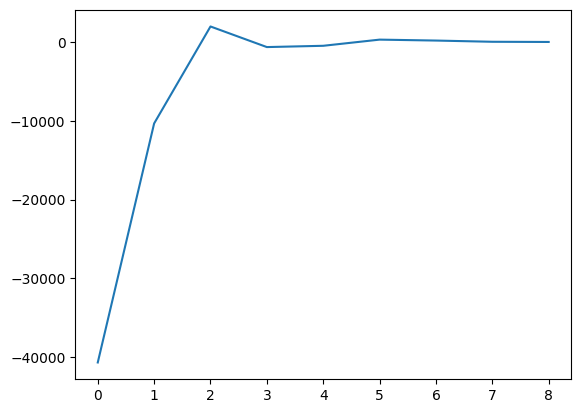

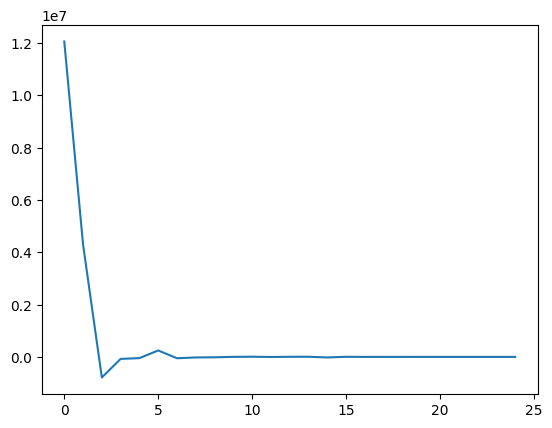

MGD L6: tensor([ True, False, False,  True, False,  True,  True, False, False])
REG L6: tensor([ True,  True, False,  True,  True, False, False, False, False])
MGD L6 psi: tensor([False, False, False,  True, False, False,  True,  True, False, False,
        False,  True, False,  True,  True,  True,  True, False, False, False,
         True,  True,  True,  True,  True])
REG L6 psi tensor([False, False,  True,  True,  True, False,  True,  True,  True, False,
        False,  True, False, False,  True, False,  True, False, False, False,
        False, False, False, False, False])


In [39]:
final_reg_vals_L6 = final_reg_vals[:9]
final_reg_vals_L6_psi = final_reg_vals[9:34] 
final_mgd_vals_L6 = final_mgd_vals[:9]
final_mgd_vals_L6_psi = final_mgd_vals[9:34] 
#plt.plot(final_mgd_vals_L6) 
plt.plot(final_reg_vals_L6) 
plt.show() 
#plt.plot(final_mgd_vals_L6_psi) 
plt.plot(final_reg_vals_L6_psi) 
plt.show() 

print("MGD L6:", final_mgd_vals_L6 < 0) 
print("REG L6:", final_reg_vals_L6 < 0) 
print("MGD L6 psi:", final_mgd_vals_L6_psi < 0) 
print("REG L6 psi", final_reg_vals_L6_psi < 0) 

## KL divergence 

In [16]:
seed_keys = sorted(results.keys(), key=lambda k: int(k.replace("seed", "")))
theta_t_list = [results[k]['theta_t'].to(device) for k in seed_keys]
theta_reg_t_list = [results[k]['Theta_reg'].to(device) for k in seed_keys]
phi_X_list   = [results[k]['phi_X'].to(device) for k in seed_keys]

print("Computing KL divergence for MGD...")
kl_mgd = compute_expected_kl_divergence(theta_t_list, phi_X_list).cpu()
kl_reg = compute_expected_kl_divergence(theta_reg_t_list, phi_X_list).cpu()

print(kl_mgd.shape)
print(kl_reg.shape) 
kl_mgd[:10]

Computing KL divergence for MGD...
torch.Size([39704])
torch.Size([197])


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

Final KL value for MGD and for REG: 0.0, 0.0
Cramer Rao bound: 0.0203


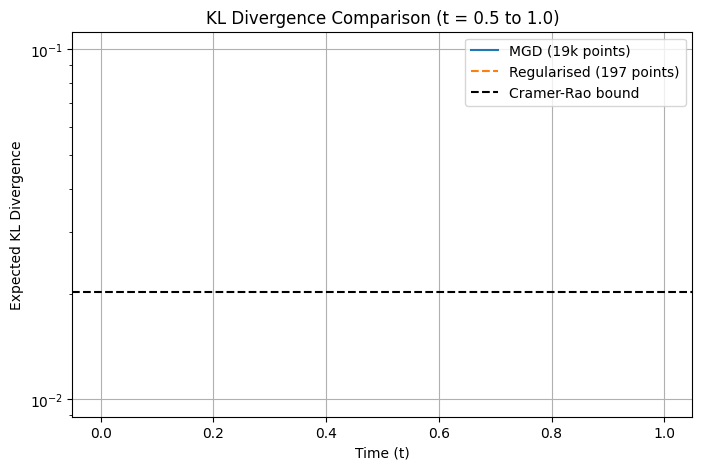

In [17]:
kl_mgd_np = kl_mgd.detach().cpu().numpy()
kl_reg_np = kl_reg.detach().cpu().numpy()

num_features = next(iter(results.values()))['phi_X'].shape[1]  # instead of the old global phi_X


print(f"Final KL value for MGD and for REG: {kl_mgd_np[-1]}, {kl_reg_np[-1]}") 
print(f"Cramer Rao bound: {num_features / (2 * n1)}") 
t_mgd = np.linspace(0, 1, len(kl_mgd_np))
t_reg = np.linspace(0, 1, len(kl_reg_np))
mask_mgd = t_mgd >= 0.0
mask_reg = t_reg >= 0.0

%matplotlib inline
plt.figure(figsize=(8, 5))
plt.plot(t_mgd[mask_mgd], kl_mgd_np[mask_mgd], label="MGD (19k points)")
plt.plot(t_reg[mask_reg], kl_reg_np[mask_reg], label="Regularised (197 points)", linestyle="--")
plt.axhline(num_features / (2 * n1), color="black", linestyle="--", label="Cramer-Rao bound")
plt.xlabel("Time (t)")
plt.ylabel("Expected KL Divergence")
plt.yscale("log")
plt.title("KL Divergence Comparison (t = 0.5 to 1.0)")
plt.legend()
plt.grid(True)
plt.show()

## Normalising constant 

In [18]:
import re

def _sigma_from_label(label: str) -> float:
    """Extract the numeric sigma value from a label like 'sigma = 20.0'."""
    m = re.search(r'sigma\s*=\s*([0-9.]+)', label)
    if m is None:
        raise ValueError(f"Could not parse sigma from label: {label!r}")
    return float(m.group(1))


def _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point):
    """Final-time entropy bound H_sigma* = H(p_0) + cumulative integral of dH."""
    dH_t_bound = dH_t_bound.detach().cpu()
    t_used = t_used.detach().cpu()
    nt_val = nt if nt is not None else t_used.shape[0]

    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound_full = dH_t_bound.cumsum(0) / nt_val + H_p_0

    # Guard against dH_t_bound/t length mismatch (same issue as plot_entropy_curves)
    min_len = min(t_used.shape[0], H_t_bound_full.shape[0])
    H_final = H_t_bound_full[min_len - last_point].item()
    return H_p_0, H_final, d


def plot_negentropy_convergence(
    x_ref: torch.Tensor,
    results: Dict[str, Dict],
    last_point=1,
    nt: Optional[int] = None,
) -> pd.DataFrame:
    """
    Reproduce Fig. 7 style plots across a sweep of sigma experiments:
      (a) ΔH_σ* = H(p_0) - H_σ*         vs sigma^2
      (b) d^-1 (H_σmax* - H_σ*)         vs sigma^2, log-log, with sigma^-2 reference
    Requires >=2 experiments, each with a 'sigma = <value>' label.
    """
    sigmas, H_finals, ds = [], [], []
    H_p_0 = None
    for key, res in results.items():
        sigma_val = _sigma_from_label(key)
        t_used = results[key]['t']
        dH_t_bound = results[key]['dH_t_bound']
        print(dH_t_bound) 
        H_p_0, H_final, d = _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point)
        sigmas.append(sigma_val)
        H_finals.append(H_final)
        ds.append(d)

    sigmas = np.array(sigmas)
    H_finals = np.array(H_finals)
    d = ds[0]  # assumes same dimensionality across all experiments

    order = np.argsort(sigmas)
    sigmas, H_finals = sigmas[order], H_finals[order]
    sigma2 = sigmas ** 2
    negentropy = H_p_0 - H_finals

    # Reference run: largest sigma in the sweep
    idx_max = np.argmax(sigmas)
    H_max = H_finals[idx_max]
    conv = np.abs(H_max - H_finals) / d

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) negentropy vs sigma^2
    axes[0].plot(sigma2, negentropy, 'o--', color='tab:blue')
    axes[0].set_xlabel(r'$\sigma^2$')
    axes[0].set_ylabel(r'$\Delta H_*^\sigma$')
    axes[0].set_title('Negentropy estimate')
    axes[0].grid(True, ls=':', alpha=0.4)

    # (b) convergence vs sigma_max, log-log (drop the sigma_max point: diff = 0)
    mask = np.arange(len(sigmas)) != idx_max
    axes[1].loglog(sigma2[mask], conv[mask], 'o', color='tab:blue', label='data')

    x_line = np.geomspace(sigma2[mask].min(), sigma2[mask].max(), 50)
    c = conv[mask][0] * sigma2[mask][0] ** 2  # anchor sigma^-2 line to first point
    #axes[1].plot(x_line, c / x_line ** 2, '-', color='tab:blue',linewidth=1.5, label=r'$\sigma^{-2}$')

    axes[1].set_xlabel(r'$\sigma^2$')
    axes[1].set_ylabel(r'$d^{-1}(H_*^{\sigma_{\max}} - H_*^\sigma)$')
    axes[1].set_title(fr'Convergence ($\sigma^2_{{\max}}$={sigma2[idx_max]:.2g})')
    axes[1].legend(frameon=False, fontsize=9)
    axes[1].grid(True, which='both', ls=':', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        'sigma': sigmas, 'sigma2': sigma2,
        'H_final': H_finals, 'negentropy': negentropy,
        'convergence': conv,
    })

def compute_m1(xt, potentials, device):
    """
    m1 = E_{p_theta_1}[phi] estimated from final-time particles xt.
    xt: [B, ...] e.g. [5000, 1, 256]
    """
    xt = xt.to(device)
    feats = []
    with torch.no_grad():
        for p in potentials.values():
            p.to(device)
            f = p(xt)
            if f.ndim == 1:
                f = f.unsqueeze(1)
            feats.append(f)
    phi_xt = torch.cat(feats, dim=-1)   # [B, 166]
    return phi_xt.mean(dim=0)           # [166]


def compute_log_Z_sigma(x_ref, results, key, theta_key, potentials, device, nt=None, last_point=1):
    """
    log Z_sigma = H_final - theta_1^T m_1

    Args:
        key:       results dict key for the sigma=3.5 run (from _sigma_from_label)
        theta_key: 'theta_t' for MGD or 'Theta_reg' for REG
    """
    dH_t_bound = results[key]['dH_t_bound']
    t_used = results[key]['t']
    _, H_final, _ = _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point)

    theta_1 = results[key][theta_key][-1].to(device)  # [166]
    xt = results[key]['xt']                            # [5000, 1, 256]
    m1 = compute_m1(xt, potentials, device)             # [166]

    log_Z_sigma = H_final - (theta_1 @ m1).item()
    return log_Z_sigma, m1

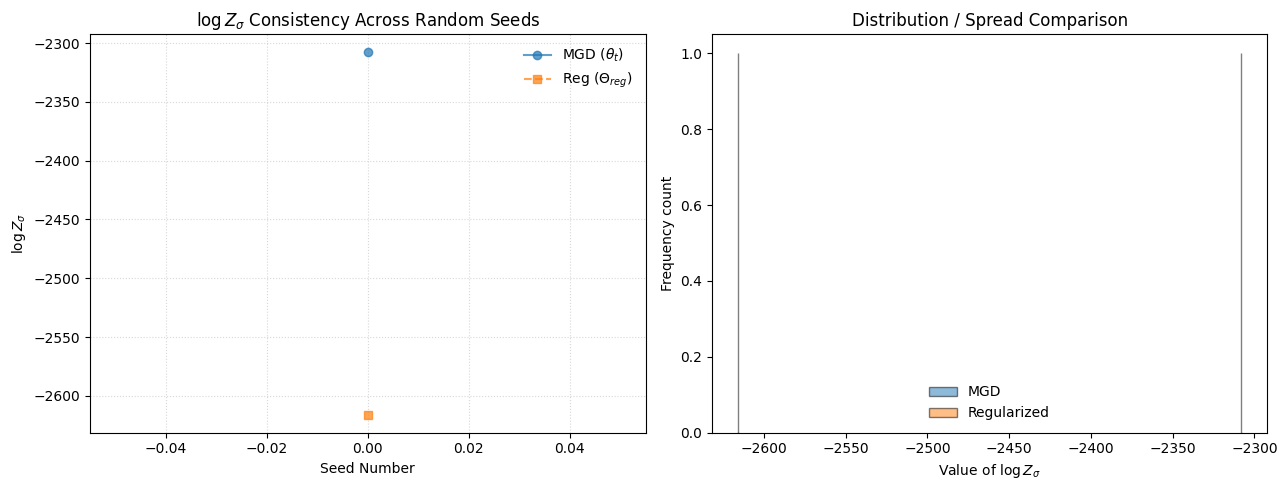

MGD Mean: -2308.0031  | Std Dev: 0.0000
Reg Mean: -2615.9277  | Std Dev: 0.0000


In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

seed_numbers = []
logZ_mgd_list, logZ_reg_list = [], []
m1_mgd_list, m1_reg_list = [], []

for key in results.keys():
    match = re.search(r'\d+', key)
    if not match:
        continue
    seed_idx = int(match.group())

    potentials_k = get_potentials_for_seed(key, M, base_args, root, device)

    logZ_mgd, m1_mgd = compute_log_Z_sigma(x1, results, key, 'theta_t', potentials_k, device)
    logZ_reg, m1_reg = compute_log_Z_sigma(x1, results, key, 'Theta_reg', potentials_k, device)

    to_num = lambda x: x.detach().cpu().item() if isinstance(x, torch.Tensor) else float(x)
    to_num_m1 = lambda x: x.detach().cpu().norm().item() if isinstance(x, torch.Tensor) and x.ndim > 0 else to_num(x)

    seed_numbers.append(seed_idx)
    logZ_mgd_list.append(to_num(logZ_mgd))
    logZ_reg_list.append(to_num(logZ_reg))
    m1_mgd_list.append(to_num_m1(m1_mgd))
    m1_reg_list.append(to_num_m1(m1_reg))

order = np.argsort(seed_numbers)
seeds_sorted = np.array(seed_numbers)[order]
logZ_mgd_arr = np.array(logZ_mgd_list)[order]
logZ_reg_arr = np.array(logZ_reg_list)[order]

# 3. Plotting for Variance & Consistency Assessment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Sequential check across individual seeds
axes[0].plot(seeds_sorted, logZ_mgd_arr, 'o-', color='tab:blue', alpha=0.7, label=r'MGD ($\theta_t$)')
axes[0].plot(seeds_sorted, logZ_reg_arr, 's--', color='tab:orange', alpha=0.7, label=r'Reg ($\Theta_{reg}$)')
axes[0].set_xlabel('Seed Number')
axes[0].set_ylabel(r'$\log Z_\sigma$')
axes[0].set_title(r'$\log Z_\sigma$ Consistency Across Random Seeds')
axes[0].grid(True, ls=':', alpha=0.5)
axes[0].legend(frameon=False)

# Subplot 2: Distribution density to check variance/spread
axes[1].hist(logZ_mgd_arr, bins=12, alpha=0.5, color='tab:blue', label='MGD', edgecolor='black')
axes[1].hist(logZ_reg_arr, bins=12, alpha=0.5, color='tab:orange', label='Regularized', edgecolor='black')
axes[1].set_xlabel(r'Value of $\log Z_\sigma$')
axes[1].set_ylabel('Frequency count')
axes[1].set_title('Distribution / Spread Comparison')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Quick summary statistics check printout
print(f"MGD Mean: {logZ_mgd_arr.mean():.4f}  | Std Dev: {logZ_mgd_arr.std():.4f}")
print(f"Reg Mean: {logZ_reg_arr.mean():.4f}  | Std Dev: {logZ_reg_arr.std():.4f}")

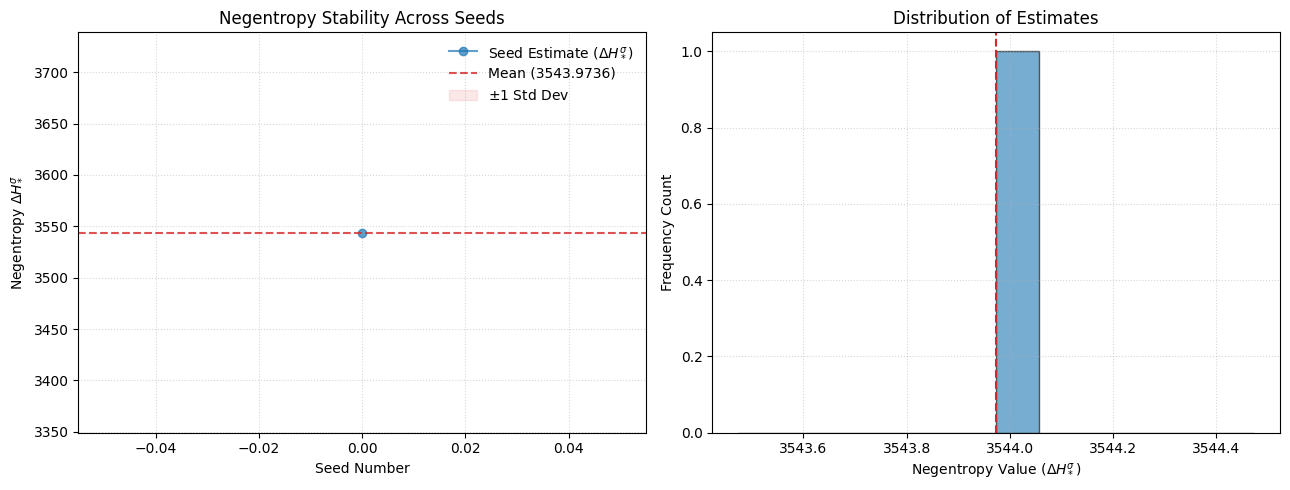

=== STATISTICAL OBSERVABLES OVER 1 SEEDS ===
Mean Negentropy : 3543.9736
Std Deviation   : 0.0000
Relative Spread : 0.000%


In [20]:
# 1. Initialize collections
seed_numbers = []
negentropy_list = []
H_finals_list = []

# Dynamically locate 't' and 'nt' from your environment if they aren't inside the results dict
global_t = locals().get('t', globals().get('t', None))
global_nt = locals().get('nt', globals().get('nt', None))

# 2. Extract and compute negentropy across all seed runs
for key, res in results.items():
    # Safely parse the integer out of "seedX"
    match = re.search(r'\d+', key)
    if not match:
        continue
    seed_idx = int(match.group())
    
    dH_t_bound = res['dH_t_bound']
    
    # Use the saved time array if available; otherwise, drop back to the global timeline
    t_used = res.get('t', global_t)
    if t_used is None:
        raise ValueError(f"Time tensor 't' not found in results['{key}'] or your current workspace.")
    
    # Reuse your structural function (passing x1 as your reference tensor)
    H_p_0, H_final, d = _entropy_bound_beforefinal(
        x_ref=x1, 
        dH_t_bound=dH_t_bound, 
        t_used=t_used, 
        nt=global_nt, 
        last_point=1
    )
    
    # Compute Negentropy: ΔH_σ* = H(p_0) - H_σ*
    negentropy_val = H_p_0 - H_final
    
    seed_numbers.append(seed_idx)
    negentropy_list.append(negentropy_val)
    H_finals_list.append(H_final)

# Sort arrays by seed number for cleaner sequential visualization
order = np.argsort(seed_numbers)
seeds_sorted = np.array(seed_numbers)[order]
negentropy_arr = np.array(negentropy_list)[order]

# Calculate statistical observables over the seed distribution
neg_mean = negentropy_arr.mean()
neg_std = negentropy_arr.std()

# 3. Plotting Consistency Profiles
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: Value vs Seed Number with a 1-sigma standard deviation band
axes[0].plot(seeds_sorted, negentropy_arr, 'o-', color='tab:blue', alpha=0.7, label=r'Seed Estimate ($\Delta H_*^\sigma$)')
axes[0].axhline(y=neg_mean, color='tab:red', ls='--', alpha=0.8, label=f'Mean ({neg_mean:.4f})')
axes[0].fill_between(seeds_sorted, neg_mean - neg_std, neg_mean + neg_std, color='tab:red', alpha=0.1, label=r'$\pm 1$ Std Dev')
axes[0].set_xlabel('Seed Number')
axes[0].set_ylabel(r'Negentropy $\Delta H_*^\sigma$')
axes[0].set_title('Negentropy Stability Across Seeds')
axes[0].grid(True, ls=':', alpha=0.5)
axes[0].legend(frameon=False)

# Right plot: Frequency density to visualize distribution geometry
axes[1].hist(negentropy_arr, bins=12, alpha=0.6, color='tab:blue', edgecolor='black')
axes[1].axvline(x=neg_mean, color='tab:red', ls='--')
axes[1].set_xlabel(r'Negentropy Value ($\Delta H_*^\sigma$)')
axes[1].set_ylabel('Frequency Count')
axes[1].set_title('Distribution of Estimates')
axes[1].grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Print Summary Metrics
print(f"=== STATISTICAL OBSERVABLES OVER {len(negentropy_arr)} SEEDS ===")
print(f"Mean Negentropy : {neg_mean:.4f}")
print(f"Std Deviation   : {neg_std:.4f}")
print(f"Relative Spread : {(neg_std / abs(neg_mean)) * 100:.3f}%")

In [21]:
print(logZ_mgd, logZ_reg) 

-2308.0030517578125 -2615.927734375


## Theta signal to noise analysis 

{'L_6': (0, 9), 'L_6_psi': (9, 34), 'L_2_lowpass': (34, 35), 'Scalar_psi_gaussianK': (35, 36), 'Scalar_morlet_gaussianK': (36, 63), 'Scattering_Fourth_Order_Mod2_Real_Q1': (63, 147), 'Scattering_Fourth_Order_Mod2_Imag_Q1': (147, 203)}
Theta_reg shape : (50, 203)
Theta_MGD shape : (50, 203)


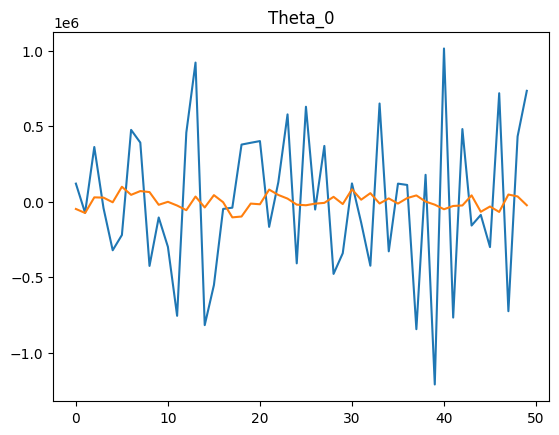

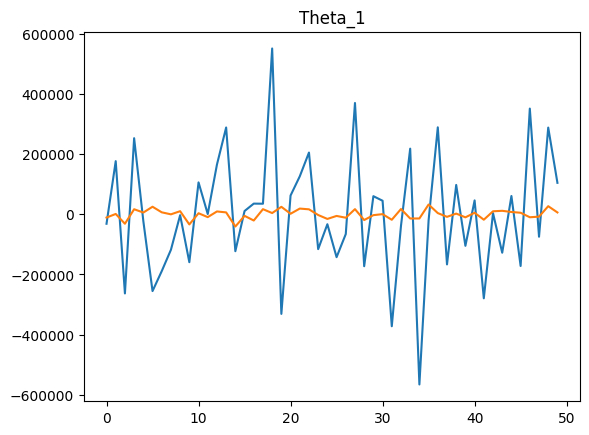

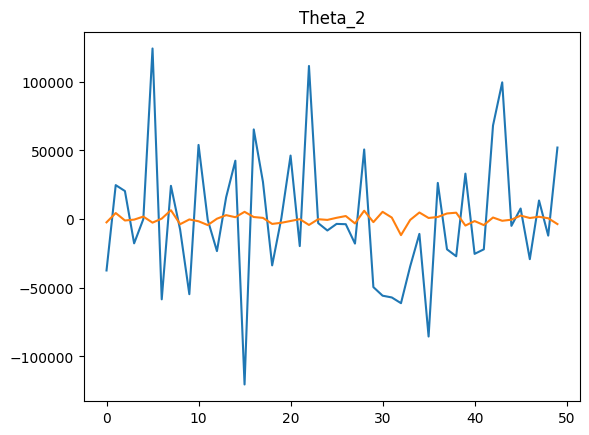

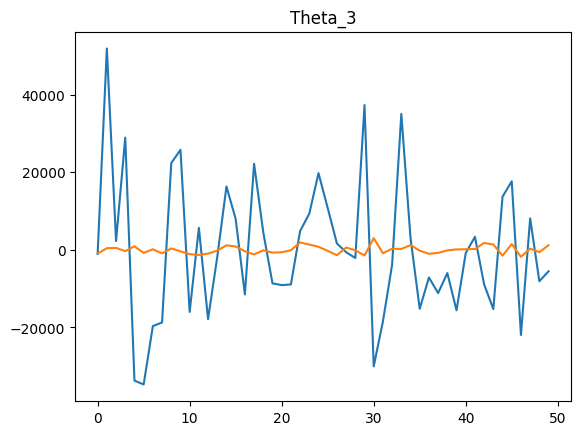

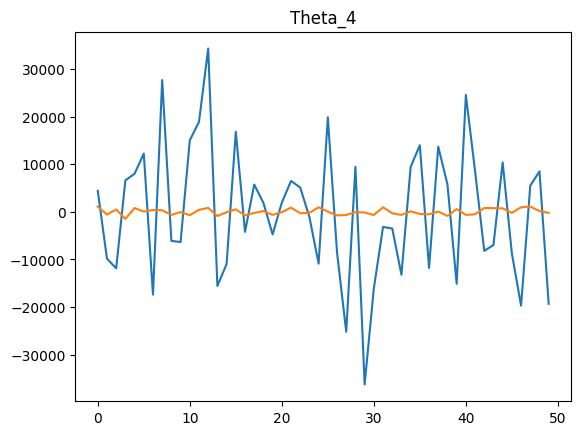

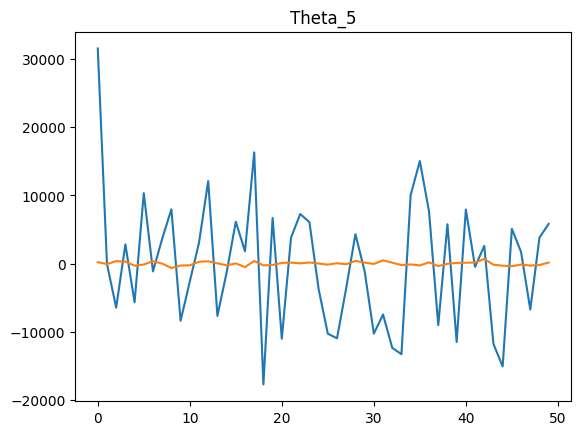

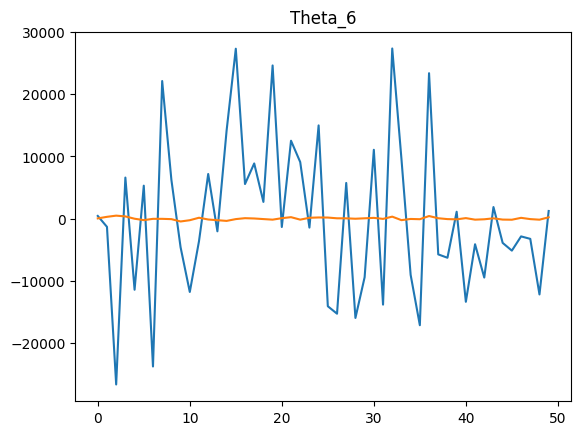

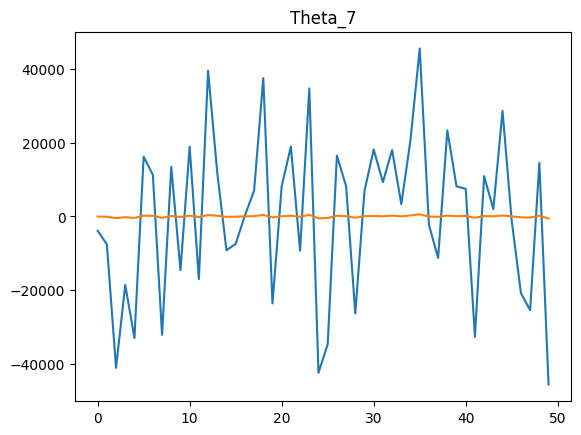

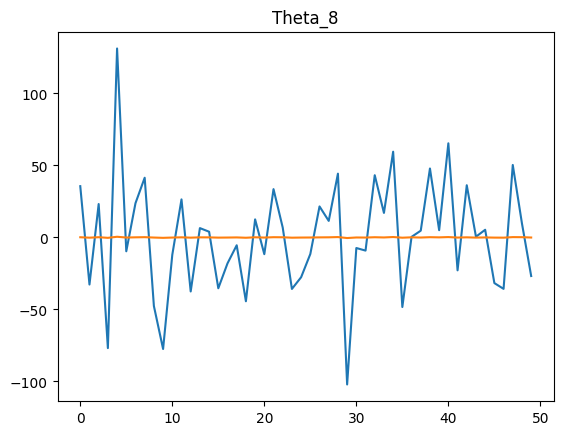

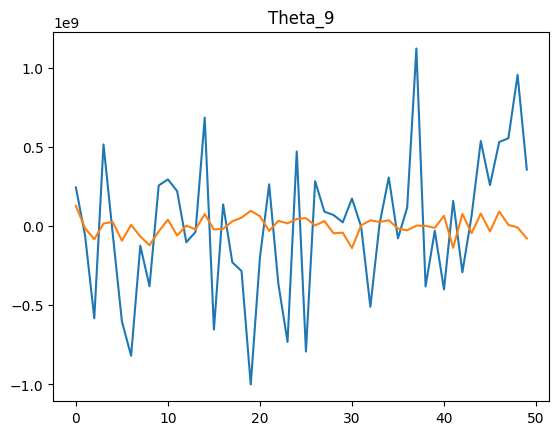

,Theta_reg mean variance,Theta_MGD mean variance,Theta_reg median variance,Theta_MGD median variance,Theta_reg mean CV,Theta_MGD mean CV,Theta_reg mean SNR,Theta_MGD mean SNR
0,2.431658e+24,7.695853e+25,272679616.0,9.707885e+10,6.064416,34.880562,36.082127,5.896692


Mean correlation : 0.19316524959545064
Median correlation : 0.1756361261661166


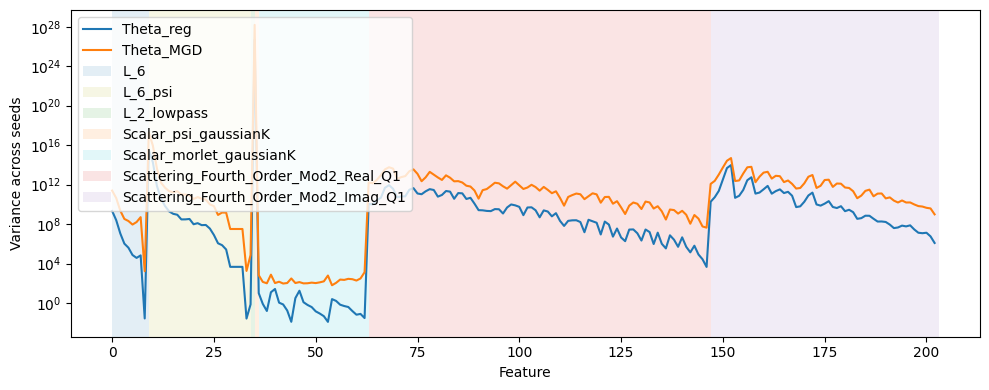

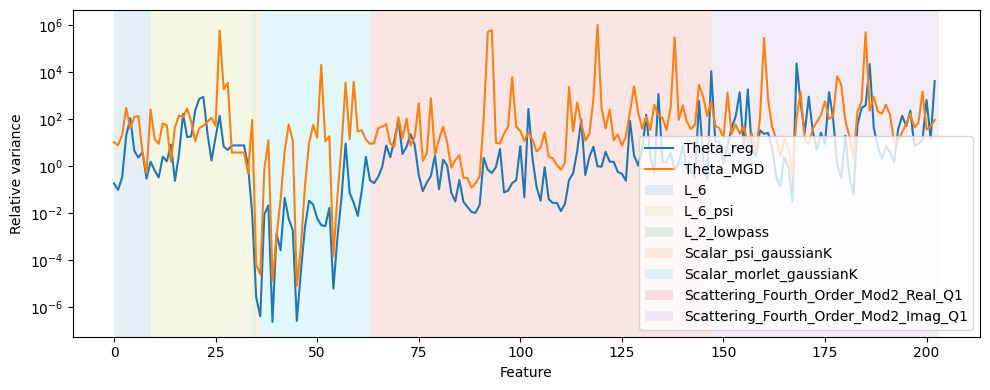

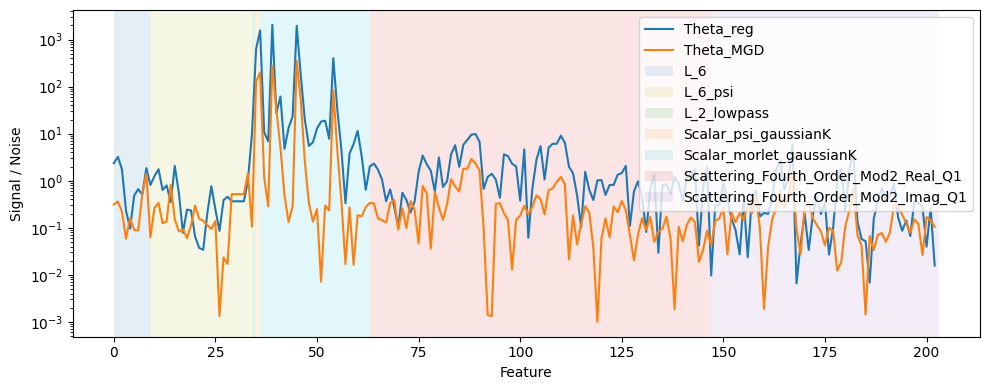

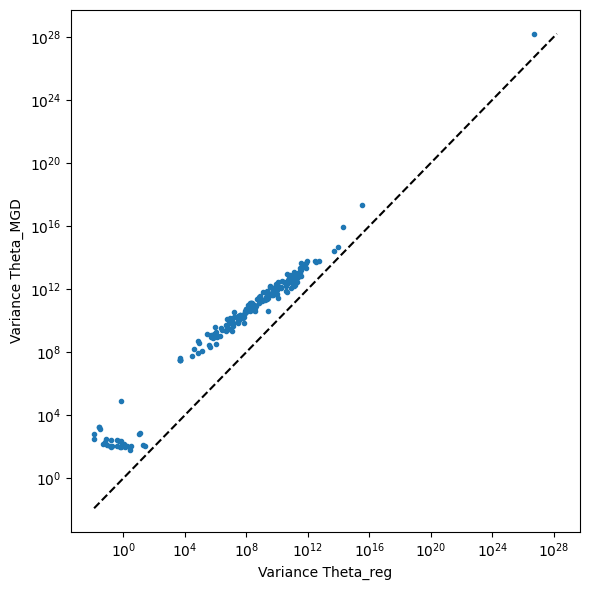

Largest Theta_reg variances
35 4.9362657e+26
9 3479981400000000.0
10 185103260000000.0
152 95261370000000.0
151 47451730000000.0
157 5512691700000.0
150 3258022400000.0
156 2791841200000.0
68 881948950000.0
161 743234900000.0

Largest Theta_MGD variances
35 1.5622581e+28
9 2.0232079e+17
10 9028696000000000.0
152 490262400000000.0
151 262175490000000.0
157 63600954000000.0
68 57732166000000.0
156 56948060000000.0
150 54211346000000.0
11 42507130000000.0


In [24]:
# ------------------------------------------------------------
# Compute theta column ranges for each potential
# ------------------------------------------------------------
# NOTE: `potentials` (built globally with scalar_param=None) does NOT reflect
# pruning that happens during fitting (e.g. Scalar_GGD_KRegion dropping regions).
# The true, per-seed coefficient counts only exist after load_fixed_parameters
# has been applied. Use an actually-fitted seed's potentials instead.
reference_key = seeds_sorted[0]  # any seed that made it into results/theta_reg
reference_seed_name = f"seed{reference_key}"

reference_potentials = get_potentials_for_seed(
    reference_seed_name, M, base_args, root, device
)

sizes = {k: p.num_coefficients for k, p in reference_potentials.items()}

potential_ranges = {}
start = 0
for name, dim in sizes.items():
    potential_ranges[name] = (start, start + dim)
    start += dim

total_from_potentials = start
assert total_from_potentials == n_features_reg == n_features_mgd, (
    f"Potential-range total ({total_from_potentials}) doesn't match the actual "
    f"feature dimension from disk (theta_reg={n_features_reg}, theta_MGD={n_features_mgd}). "
    f"This means even the reference seed's pruning differs from the pooled theta arrays — "
    f"check that all seeds in `seeds_sorted` were fit with the same active regions."
)

print(potential_ranges)
potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive", 
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan", 
}

import os
import pandas as pd

# ------------------------------------------------------------
# Load saved file
# ------------------------------------------------------------
load_path = os.path.join(root, "saved_results", "final_theta_comparison.pt")
data = torch.load(load_path, map_location="cpu")

seeds = data["seeds"]

theta_reg = np.stack([
    data["theta_reg_final"][s].numpy()
    for s in seeds
])

theta_mgd = np.stack([
    data["theta_MGD_final"][s].numpy()
    for s in seeds
])

print("Theta_reg shape :", theta_reg.shape)
print("Theta_MGD shape :", theta_mgd.shape)

n_seeds, n_features = theta_reg.shape
%matplotlib inline
for i in range(0,10): 
    plt.plot(theta_mgd[:,i] - theta_mgd[:,i].mean(axis=0)) 
    plt.plot(theta_reg[:,i] - theta_reg[:,i].mean(axis=0))
    plt.title(f"Theta_{i}") 
    plt.show() 
    
eps = 1e-12

stats = {}

for name, X in {
    "Theta_reg": theta_reg,
    "Theta_MGD": theta_mgd,
}.items():

    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    var = std**2

    cv = std / (np.abs(mean) + eps)

    rel_var = var / (mean**2 + eps)

    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(
        mean=mean,
        std=std,
        var=var,
        cv=cv,
        rel_var=rel_var,
        snr=snr,
    )

summary = pd.DataFrame({
    "Theta_reg mean variance": [stats["Theta_reg"]["var"].mean()],
    "Theta_MGD mean variance": [stats["Theta_MGD"]["var"].mean()],

    "Theta_reg median variance": [np.median(stats["Theta_reg"]["var"])],
    "Theta_MGD median variance": [np.median(stats["Theta_MGD"]["var"])],

    "Theta_reg mean CV": [stats["Theta_reg"]["cv"].mean()],
    "Theta_MGD mean CV": [stats["Theta_MGD"]["cv"].mean()],

    "Theta_reg mean SNR": [stats["Theta_reg"]["snr"].mean()],
    "Theta_MGD mean SNR": [stats["Theta_MGD"]["snr"].mean()],
})

display(summary)
corrs = []

for j in range(n_features):
    c = np.corrcoef(theta_reg[:, j], theta_mgd[:, j])[0,1]
    corrs.append(c)

corrs = np.array(corrs)

print("Mean correlation :", np.nanmean(corrs))
print("Median correlation :", np.nanmedian(corrs))

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Variance across seeds")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["rel_var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["rel_var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Relative variance")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.plot(stats["Theta_reg"]["snr"], label="Theta_reg")
plt.plot(stats["Theta_MGD"]["snr"], label="Theta_MGD")
plt.yscale("log") 
plt.xlabel("Feature")
plt.ylabel("Signal / Noise")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))

plt.loglog(
    stats["Theta_reg"]["var"],
    stats["Theta_MGD"]["var"],
    "."
)

xmin = min(
    stats["Theta_reg"]["var"].min(),
    stats["Theta_MGD"]["var"].min()
)
xmax = max(
    stats["Theta_reg"]["var"].max(),
    stats["Theta_MGD"]["var"].max()
)

plt.plot([xmin,xmax],[xmin,xmax],"k--")

plt.xlabel("Variance Theta_reg")
plt.ylabel("Variance Theta_MGD")
plt.tight_layout()
plt.show()

idx = np.argsort(stats["Theta_reg"]["var"])[::-1]

print("Largest Theta_reg variances")
for i in idx[:10]:
    print(i, stats["Theta_reg"]["var"][i])

print()

idx = np.argsort(stats["Theta_MGD"]["var"])[::-1]

print("Largest Theta_MGD variances")
for i in idx[:10]:
    print(i, stats["Theta_MGD"]["var"][i])

(50, 203)